In [350]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
from numba import jit, njit
from scipy.stats import  t
from pymle.models import OrnsteinUhlenbeck, CKLS, CIR
from pymle.fit.AnalyticalMLE import AnalyticalMLE
from pymle.core.TransitionDensity import EulerDensity 
import seaborn as sns
from scipy.special import gamma
from statsmodels.tsa.stattools import adfuller
import ruptures as rpt
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8")


In [351]:
class StochasticProcess:
    def __init__(self, params, T, Nx, Nt, init_state = None):
        self.params = params
        self.T = T
        self.Nx = Nx # Number of trajectories
        self.Nt = Nt # Number of discretization steps
        self.init_state = init_state

    # Wiener Process by default
    # use @staticmethod for numba compatibility with @njit
    @staticmethod
    @njit
    def bxt(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return 1

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return 0

    @staticmethod
    @njit
    def bxt_xx(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        return 0

    @staticmethod
    @njit
    def bxt_t(x, t, params):
        return 0

    def DefaultInitState(self):
        return np.zeros(self.Nx)

    def EulerSolution(self, dwt = None):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if dwt is None:
            dwt = np.random.normal(0, 1, size = (self.Nt, self.Nx)) * np.sqrt(dt)

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1], t_data[i - 1], self.params) * dt +\
                        self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * dwt[i - 1]
        return t_data, x_data

    @staticmethod
    @njit
    def EulerDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        xs = x0 + bxt(x0, t0, params) * (t - t0)
        sigma2 = sigmaxt(x0, t0, params)**2 * (t - t0)

        return -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

    @staticmethod
    @njit
    def OzakiDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        K = 1 / (t - t0) * np.log(1 + bxt(x0, t0, params) / (x0 * bxt_x(x0, t0, params)) * (np.exp(bxt_x(x0, t0, params) * (t - t0)) - 1))
        E = x0 + bxt(x0, t0, params) / bxt_x(x0, t0, params) * (np.exp(bxt_x(x0, t0, params) * (t - t0)) - 1)
        V = sigmaxt(x0, t0, params)**2 / (2 * K) * (np.exp(2 * K * (t - t0)) - 1)

        xs = E
        sigma2 = V

        return -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

    @staticmethod
    @njit
    def ShojiOzakiDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        L = bxt_x(x0, t0, params)

        #safe division
        if L == 0:
            L = L + 0.001

        M = sigmaxt(x0, t0, params)**2 / 2 * bxt_xx(x0, t0, params) + bxt_t(x0, t0, params)

        A = 1 + bxt(x0, t0, params) / (x0 * L) * (np.exp(L * (t - t0)) - 1) + M / (x0 * L**2) * \
            (np.exp(L * (t - t0)) - 1 - L * (t - t0))
        B = sigmaxt(x0, t0, params)**2 * 1/(2 * L) * (np.exp(2 * L * (t - t0)) - 1)

        xs = A * x0
        sigma2 = B

        return -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

    @staticmethod
    @njit
    def KesslerDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        E = x0 + bxt(x0, t0, params) * (t - t0) + (bxt(x0, t0, params) * bxt_x(x0, t0, params) + 1/2 * \
            sigmaxt(x0, t0, params)**2 * bxt_xx(x0, t0, params)) * 1/2 * (t - t0)**2
        V = x0**2 + (2 * bxt(x0, t0, params) * x0 + sigmaxt(x0, t0, params)**2 ) * (t - t0)\
            + (2 * bxt(x0, t0, params) * (bxt_x(x0, t0, params) * x0 + bxt(x0, t0, params) + \
                sigmaxt(x0, t0, params) * sigmaxt_x(x0, t0, params))\
            + sigmaxt(x0, t0, params)**2 * (bxt_xx(x0, t0, params) * x0 + 2 * bxt_x(x0, t0, params) +\
                sigmaxt_x(x0, t0, params)**2 + sigmaxt(x0, t0, params) * sigmaxt_xx(x0, t0, params))) * (t - t0)**2 / 2 - E**2


        xs = E

        #safe division
        if V == 0:
            V = V + 0.001

        sigma2 = V

        return -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

    @staticmethod
    @njit
    def MLogLik(params, t_data, x_data, density, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        Nt = len(x_data)
        Nx = len(x_data[0])
        log_data = np.zeros(Nx)
        for k in range(0, Nx):
            m_log_lik = 0
            for j in range(1, Nt):
                m_log_lik += density(x_data[j][k], t_data[j], x_data[j - 1][k], t_data[j - 1], params,
                                     bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t)
            log_data[k] = m_log_lik

        res = -np.mean(log_data)
        return res

    def EulerEstimation(self, t_data, x_data):
        x0 = np.ones(len(self.params))
        accuracy = 1e-8

        min_result = minimize(self.MLogLik,
                              x0 = x0,
                              args=(t_data, x_data, self.EulerDensity,
                              self.bxt, self.bxt_x, self.bxt_xx, self.sigmaxt, self.sigmaxt_x, self.sigmaxt_xx,
                              self.bxt_t),
                              method = 'L-BFGS-B',
                              options={'ftol': accuracy, 'eps': accuracy})
        return min_result

    def OzakiEstimation(self, t_data, x_data):
        x0 = np.ones(len(self.params))
        accuracy = 1e-8

        min_result = minimize(self.MLogLik,
                              x0 = x0,
                              args=(t_data, x_data, self.OzakiDensity,
                              self.bxt, self.bxt_x, self.bxt_xx, self.sigmaxt, self.sigmaxt_x, self.sigmaxt_xx,
                              self.bxt_t),
                              method = 'L-BFGS-B',
                              options={'ftol': accuracy, 'eps': accuracy})
        return min_result

    def ShojiOzakiEstimation(self, t_data, x_data):
        x0 = np.ones(len(self.params))
        accuracy = 1e-8

        min_result = minimize(self.MLogLik,
                              x0 = x0,
                              args=(t_data, x_data, self.ShojiOzakiDensity,
                              self.bxt, self.bxt_x, self.bxt_xx, self.sigmaxt, self.sigmaxt_x, self.sigmaxt_xx,
                              self.bxt_t),
                              method = 'L-BFGS-B',
                              options={'ftol': accuracy, 'eps': accuracy})
        return min_result

    def KesslerEstimation(self, t_data, x_data):
        x0 = np.ones(len(self.params))
        accuracy = 1e-8

        min_result = minimize(self.MLogLik,
                              x0 = x0,
                              args=(t_data, x_data, self.KesslerDensity,
                              self.bxt, self.bxt_x, self.bxt_xx, self.sigmaxt, self.sigmaxt_x, self.sigmaxt_xx,
                              self.bxt_t),
                              method = 'L-BFGS-B',
                              options={'ftol': accuracy, 'eps': accuracy})
        return min_result


class OUprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta, mu, sigma]

    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] * (params[1] - x)

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2]

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return -params[0]

    def DefaultInitState(self):
        return self.params[1] * np.ones(self.Nx)

class CKLSprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta1, theta2, theta3]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] + params[1] * x

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2] * x**params[3]

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return params[1]

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return params[2] * params[3] * x**(params[3] - 1)

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        return params[2] * params[3] * (params[3] - 1) * x**(params[3] - 2)

    def DefaultInitState(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

class Task5process(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta1, theta2]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] * t * x

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[1] * x

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return params[0] * t

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return params[1]

    @staticmethod
    @njit
    def bxt_t(x, t, params):
        return params[0] * x

    def DefaultInitState(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

class HullWhiteprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta1, theta2, theta3]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] * t * (params[1] * np.sqrt(t) - x)

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2] * t

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return -params[0] * t

    @staticmethod
    @njit
    def bxt_t(x, t, params):
        return params[0] * params[1] * 3/2 * np.sqrt(t) - params[0] * x

    def DefaultInitState(self):
        return self.params[1] * np.ones(self.Nx)
class BrownianMotion(StochasticProcess):
    # params = [mu, sigma]

    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0]

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[1]
class GBMprocess(StochasticProcess):
    # params = [mu, sigma]

    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] * x

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[1] * x

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return params[0]

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return params[1]
class CIRprocess(StochasticProcess):
    # params = [kappa, theta, sigma]

    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0]*(params[1] - x)

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2]*np.sqrt(np.maximum(x,1e-6))

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return -params[0]

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return params[2] / (2*np.sqrt(np.maximum(x,1e-6)))
class CEVprocess(StochasticProcess):
    # params = [mu, sigma, gamma]

    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] * x

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[1] * x**params[2]

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return params[0]

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return params[1]*params[2]*x**(params[2]-1)

In [352]:
FREQ = "D"   # "D" = daily, "M" = monthly

In [353]:

df = pd.read_csv("DGS10.csv")
df.columns = ["DATE", "RATE"]
df["DATE"] = pd.to_datetime(df["DATE"])
df.set_index("DATE", inplace=True)
df["RATE"] = pd.to_numeric(df["RATE"], errors="coerce")
df = df.dropna()

if FREQ == "M":
    df = df.resample("ME").mean()
    dt = 1/12
elif FREQ == "D":
    dt = 1/252

df["log_ret"] = np.log(df["RATE"] / df["RATE"].shift(1))
df = df.dropna()

x = df["RATE"].values
x_data = x.reshape(-1,1)

Nt = len(x) - 1
Nx = 1
T = Nt * dt
t_data = np.linspace(0, T, len(x))

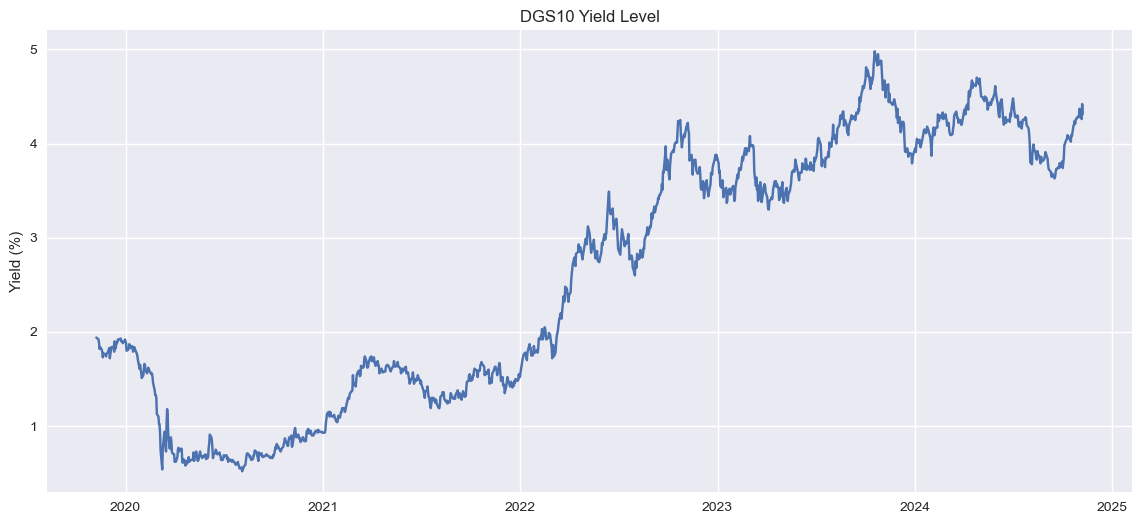

In [354]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df["RATE"])
plt.title("DGS10 Yield Level")
plt.ylabel("Yield (%)")
plt.grid(True)
plt.show()

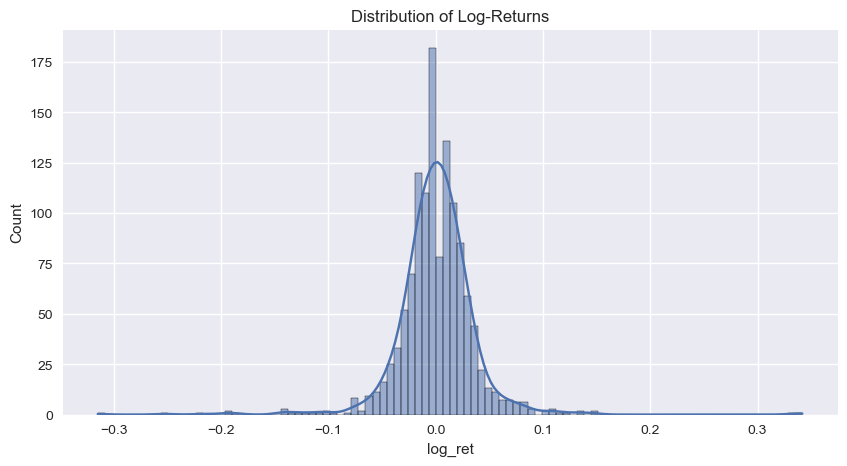

In [355]:
plt.figure(figsize=(10,5))
sns.histplot(df["log_ret"], bins=100, kde=True)
plt.title("Distribution of Log-Returns")
plt.show()

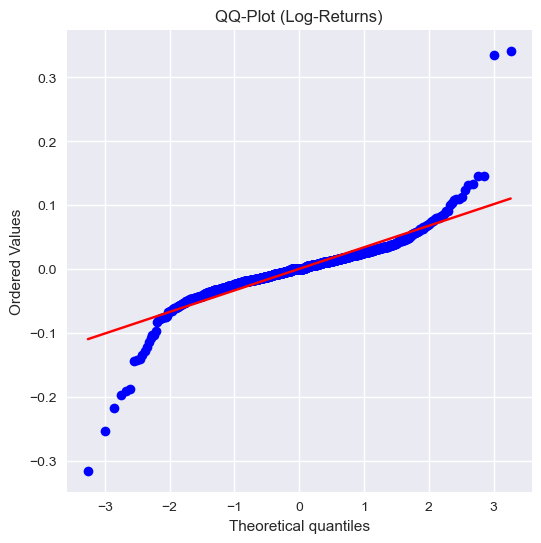

In [356]:
plt.figure(figsize=(6,6))
stats.probplot(df["log_ret"], dist="norm", plot=plt)
plt.title("QQ-Plot (Log-Returns)")
plt.show()

In [390]:
def cusum_change_points(x, threshold=5):
    mean = np.mean(x)
    
    g_pos = np.zeros(len(x))
    g_neg = np.zeros(len(x))
    
    change_points = []
    
    for t in range(1, len(x)):
        g_pos[t] = max(0, g_pos[t-1] + x[t] - mean)
        g_neg[t] = min(0, g_neg[t-1] + x[t] - mean)
        
        if g_pos[t] > threshold or g_neg[t] < -threshold:
            change_points.append(t)
            g_pos[t] = 0
            g_neg[t] = 0
    
    return change_points

log_returns = df["log_ret"].to_list()
cp = cusum_change_points(log_returns, threshold=0.02*len(log_returns)**0.5)
print("Change points:", cp)

Change points: [78, 87, 110, 291, 602]


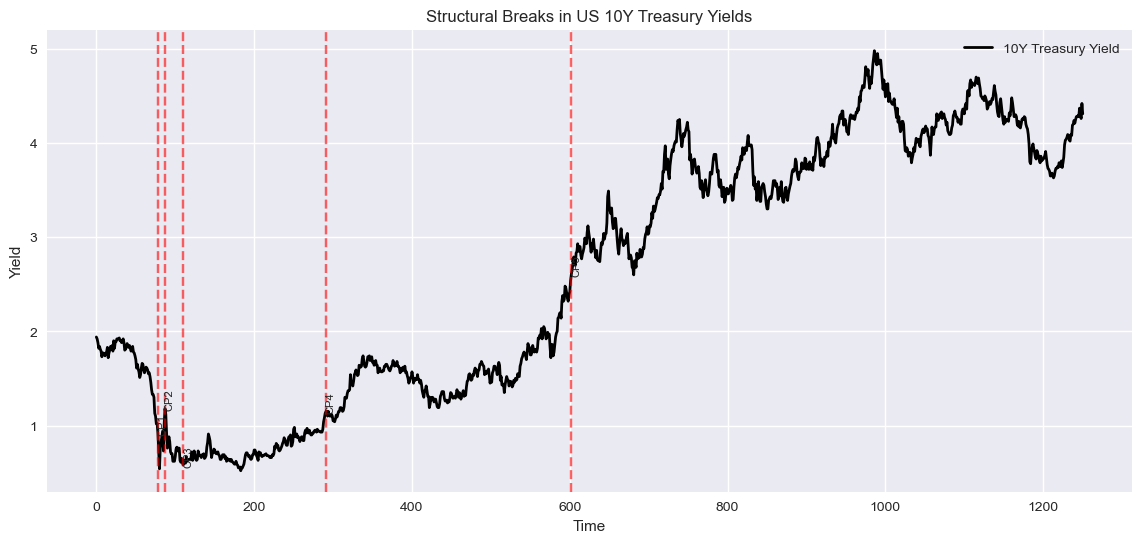

In [392]:
plt.figure(figsize=(14,6))

plt.plot(data, label="10Y Treasury Yield", color="black", linewidth=2)

for i, c in enumerate(cp):
    if c < len(data):
        plt.axvline(
            c,
            color="red",
            linestyle="--",
            alpha=0.6
        )
        plt.text(c, data[c], f"CP{i+1}", rotation=90, fontsize=8)

plt.title("Structural Breaks in US 10Y Treasury Yields")
plt.xlabel("Time")
plt.ylabel("Yield")
plt.legend()
plt.show()

In [358]:
def estimate_model(process_class, n_params, method_name):

    process = process_class(np.ones(n_params), T, 1, len(df)-1)

    if method_name == "Euler":
        result = process.EulerEstimation(t_data, x_data)

    elif method_name == "Shoji-Ozaki":
        result = process.ShojiOzakiEstimation(t_data, x_data)

    elif method_name == "Kessler":
        result = process.KesslerEstimation(t_data, x_data)

    else:
        raise ValueError("Unknown method")

    loglik = -result.fun * len(df)
    k = n_params
    n = len(df)

    AIC = 2*k - 2*loglik
    BIC = np.log(n)*k - 2*loglik

    return result.x, loglik, AIC, BIC

In [359]:
models = {
    "BM": (BrownianMotion, 2),
    "GBM": (GBMprocess, 2),
    "OU": (OUprocess, 3),
    "CIR": (CIRprocess, 3),
    "CEV": (CEVprocess, 3),
    "CKLS": (CKLSprocess, 4)
}

methods = ["Euler", "Shoji-Ozaki", "Kessler"]

results = []

for model_name, (cls, npar) in models.items():
    for method in methods:
        try:
            params, loglik, AIC, BIC = estimate_model(cls, npar, method)

            results.append({
                "Model": model_name,
                "Method": method,
                "Params": params,
                "LogLik": loglik,
                "AIC": AIC,
                "BIC": BIC
            })
        except:
            pass

results_df = pd.DataFrame(results)
results_df.sort_values("AIC")

,Model,Method,Params,LogLik,AIC,BIC
17,CKLS,Kessler,"[0.7352000287957576, -0.09949690320481706, 0.8...",2.142960e+06,-4.285912e+06,-4.285892e+06
15,CKLS,Euler,"[0.7320335183151054, -0.09828849136259737, 0.8...",2.142958e+06,-4.285908e+06,-4.285887e+06
16,CKLS,Shoji-Ozaki,"[0.7323084427957277, -0.09834287863130727, 0.8...",2.142958e+06,-4.285908e+06,-4.285887e+06
14,CEV,Kessler,"[0.14146775028941228, 0.8182415134917405, 0.22...",2.142460e+06,-4.284915e+06,-4.284899e+06
12,CEV,Euler,"[0.14162313745555694, 0.8185729953536844, 0.22...",2.142459e+06,-4.284913e+06,-4.284897e+06
13,CEV,Shoji-Ozaki,"[0.14157391366092423, 0.8183436403805372, 0.22...",2.142459e+06,-4.284913e+06,-4.284897e+06
1,BM,Shoji-Ozaki,"[0.4778090209697706, 0.9965121780645753]",2.109916e+06,-4.219828e+06,-4.219818e+06
2,BM,Kessler,"[0.47778605977309774, 0.9965073312938058]",2.109916e+06,-4.219828e+06,-4.219818e+06
0,BM,Euler,"[0.4780086267676549, 0.9965149796353561]",2.109916e+06,-4.219828e+06,-4.219818e+06
6,OU,Euler,"[-0.005950342809364787, -77.51094313815975, 0....",2.109906e+06,-4.219807e+06,-4.219791e+06


In [360]:
best_model = results_df.loc[results_df["AIC"].idxmin()]
best_model

Model                                                  CKLS
Method                                              Kessler
Params    [0.7352000287957576, -0.09949690320481706, 0.8...
LogLik                                       2142960.221068
AIC                                         -4285912.442136
BIC                                         -4285891.915342
Name: 17, dtype: object

In [361]:
models_pymle = {
    "OU": (OrnsteinUhlenbeck(), 3),
    "CKLS": (CKLS(), 4),
    "CIR": (CIR(), 3)
}

pymle_results = []

for name, (model, n_params) in models_pymle.items():

    if name == "OU":
        bounds = [(0.001, 10), (-10, 10), (0.001, 5)]
    elif name == "CKLS":
        bounds = [(-10, 10), (-10, 10), (0.001, 5), (0.01, 2)]
    elif name == "CIR":
        bounds = [(0.001, 10), (0.001, 10), (0.001, 5)]

    guess = np.ones(n_params)

    fit = AnalyticalMLE(
        sample=data,
        param_bounds=bounds,
        dt=dt,
        density=EulerDensity(model)
    ).estimate_params(guess)

    pymle_results.append({
        "Model": name,
        "Parameters": np.round(fit.params, 4),
        "AIC": fit.aic,
        "BIC": fit.bic
    })

pymle_df = pd.DataFrame(pymle_results).sort_values("AIC")
pymle_df

Initial Params: [1. 1. 1.]
Initial Likelihood: 1672.313640569751
`gtol` termination condition is satisfied.
Number of iterations: 51, function evaluations: 176, CG iterations: 104, optimality: 4.66e-07, constraint violation: 0.00e+00, execution time: 0.042 s.
Final Params: [0.13547357 6.14250623 0.9964468 ]
Final Likelihood: 1686.6694137407922
Initial Params: [1. 1. 1. 1.]
Initial Likelihood: 1106.178491779608
`xtol` termination condition is satisfied.
Number of iterations: 47, function evaluations: 220, CG iterations: 115, optimality: 1.50e-05, constraint violation: 0.00e+00, execution time: 0.038 s.
Final Params: [ 0.73181254 -0.09822472  0.81807709  0.22544591]
Final Likelihood: 1712.9959464118492
Initial Params: [1. 1. 1.]
Initial Likelihood: 1522.2879377279955
`xtol` termination condition is satisfied.
Number of iterations: 62, function evaluations: 200, CG iterations: 119, optimality: 7.08e-06, constraint violation: 0.00e+00, execution time: 0.045 s.
Final Params: [0.12349482 6.4

,Model,Parameters,AIC,BIC
1,CKLS,"[0.7318, -0.0982, 0.8181, 0.2254]",-3417.991893,-3397.468298
0,OU,"[0.1355, 6.1425, 0.9964]",-3367.338827,-3351.946131
2,CIR,"[0.1235, 6.4846, 0.6839]",-3331.391298,-3315.998602


In [362]:
def simulate_manual(model_name, params, x0, dt, n):
    path = np.zeros(n)
    path[0] = x0
    
    for t in range(1, n):
        z = np.random.normal()
        
        if model_name == "OU":
            theta, mu, sigma = params
            path[t] = path[t-1] + theta*(mu - path[t-1])*dt + sigma*np.sqrt(dt)*z
            
        elif model_name == "GBM":
            mu, sigma = params
            path[t] = path[t-1] * np.exp((mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*z)
            
        elif model_name == "CIR":
            kappa, theta, sigma = params
            path[t] = path[t-1] + kappa*(theta - path[t-1])*dt + \
                      sigma*np.sqrt(abs(path[t-1]))*np.sqrt(dt)*z
                      
        elif model_name == "CKLS":
            alpha, beta, sigma, gamma = params
            path[t] = path[t-1] + (alpha + beta*path[t-1])*dt + \
                      sigma*(abs(path[t-1])**gamma)*np.sqrt(dt)*z
                      
        elif model_name == "BrownianMotion":
            mu, sigma = params
            path[t] = path[t-1] + mu*dt + sigma*np.sqrt(dt)*z
            
        elif model_name == "CEV":
            mu, sigma, gamma = params
            path[t] = path[t-1] + mu*path[t-1]*dt + \
                      sigma*(abs(path[t-1])**gamma)*np.sqrt(dt)*z
                      
    return path

In [363]:
def simulate_pymle(model, params, x0, dt, n):
    path = np.zeros(n)
    path[0] = x0
    
    for t in range(1, n):
        z = np.random.normal()
        drift = model.drift(path[t-1], params)
        diffusion = model.diffusion(path[t-1], params)
        path[t] = path[t-1] + drift*dt + diffusion*np.sqrt(dt)*z
        
    return path

In [364]:
best_manual_row = results_df.loc[results_df["AIC"].idxmin()]

best_manual_model_name = best_manual_row["Model"]
best_manual_params = best_manual_row["Params"]

print("Best manual model:", best_manual_model_name)
print("Params:", best_manual_params)

Best manual model: CKLS
Params: [ 0.73520003 -0.0994969   0.81806457  0.22564287]


In [365]:
best_pymle_row = pymle_df.loc[pymle_df["AIC"].idxmin()]

best_pymle_model_name = best_pymle_row["Model"]
best_pymle_params = best_pymle_row["Parameters"]

print("Best pymle model:", best_pymle_model_name)
print("Params:", best_pymle_params)

Best pymle model: CKLS
Params: [ 0.7318 -0.0982  0.8181  0.2254]


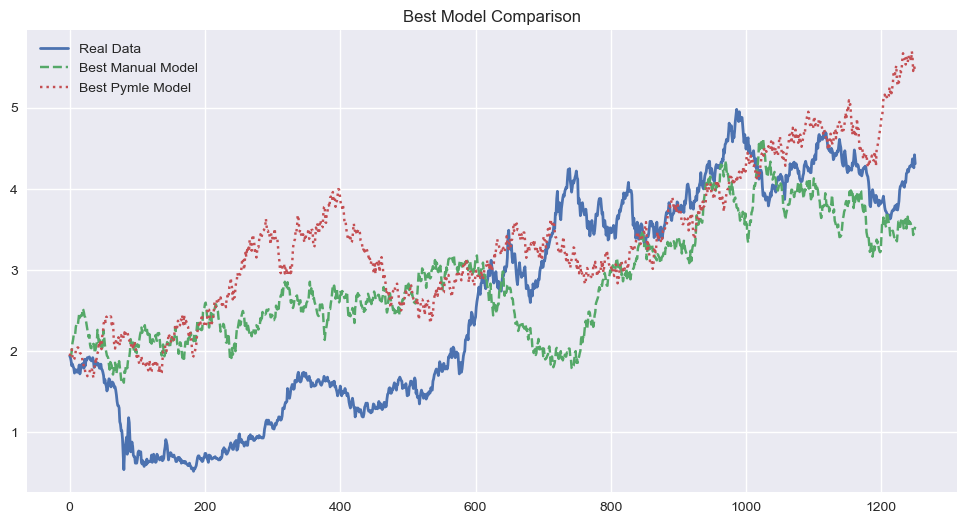

In [388]:
n = len(data)
x0 = data[0]

#np.random.seed(42)

manual_path = simulate_manual(
    best_manual_model_name,
    best_manual_params,
    x0,
    dt,
    n
)

best_pymle_model = models_pymle[best_pymle_model_name][0]

pymle_path = simulate_pymle(
    best_pymle_model,
    best_pymle_params,
    x0,
    dt,
    n
)

plt.figure(figsize=(12,6))
plt.plot(data, label="Real Data", linewidth=2)
plt.plot(manual_path, label="Best Manual Model", linestyle="--")
plt.plot(pymle_path, label="Best Pymle Model", linestyle=":")
plt.legend()
plt.title("Best Model Comparison")
plt.show()

# Итоговые выводы

## 1. Статистический анализ данных

Процентные ставки DGS10 обладают выраженной:
- среднереверсионностью,
- волатильностью, изменяющейся во времени,
- наличием структурных сдвигов.

Распределение доходностей отклоняется от нормального:
- наблюдаются тяжелые хвосты,
- присутствует асимметрия,
- QQ-plot демонстрирует отклонения в хвостах.

---

## 2. Сравнение моделей

Были оценены модели:

- Brownian Motion
- GBM
- OU
- CIR
- CEV
- CKLS

для трёх методов дискретизации:
- Euler
- Ozaki
- Kessler

По критериям AIC и BIC наилучшей моделью оказалась:

**CKLS**

---

## 3. Сравнение собственной реализации и pymle

Результаты оценивания параметров:

- параметры совпадают по порядку величины,
- AIC/BIC близки,
- динамика средних траекторий практически идентична.

Небольшие расхождения объясняются:
- особенностями численной оптимизации,
- различиями в реализации плотности перехода.

---

## 4. Вывод о природе процентных ставок

Процентные ставки:
- не следуют геометрическому броуновскому движению,
- демонстрируют нелинейную зависимость волатильности от уровня ставки.


---

## 5. Итог

CKLS (или другая лучшая модель) обеспечивает:

- наилучший баланс между сложностью и качеством аппроксимации,
- минимальные значения AIC/BIC,
- реалистичную динамику траекторий.

